In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import make_scorer


 <h2> ANS:Q1. Examine dataset size, missing values, and feature types </h2>

In [3]:

try:
    #load data from csv
    df = pd.read_csv("bike_train.csv")
    #====Exploratory Data Analysis (EDA)===
    #data strting lines 
   # print(df.head(), end="\n\n")
    #data end lines 
   # print(df.tail(), end="\n\n")
    #data stats
   # print(df.describe(), end="\n\n")
    #data info
    print(df.info(), end="\n\n")

    #====Q1. Examine dataset size, missing values, and feature types.
    #dataset size
    print(f"Number of rows in the bike train data: {df.shape[0]} ", end="\n\n")
    print(f"Number of columns in the bike train data: {df.shape[1]} ", end="\n\n")
    #missing values
    print(f"Missing values in  bike train data is: {df.isnull().sum()} ", end="\n\n")
    #feature types
    print(f"Features types in bike train data is: {df.dtypes} ", end="\n\n")
    
    

except FileNotFoundError:
    print("Error: bike_train.csv not found. Please check the file path.")
   
    
    


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  object 
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   casual      10450 non-null  int64  
 10  registered  10450 non-null  int64  
 11  count       10450 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 979.8+ KB
None

Number of rows in the bike train data: 10450 

Number of columns in the bike train data: 12 

Missing values in  bike train data is: datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
hu

 <h2> ANS: Q2. Visualize relationships between key features and the target variable (count). </h2>

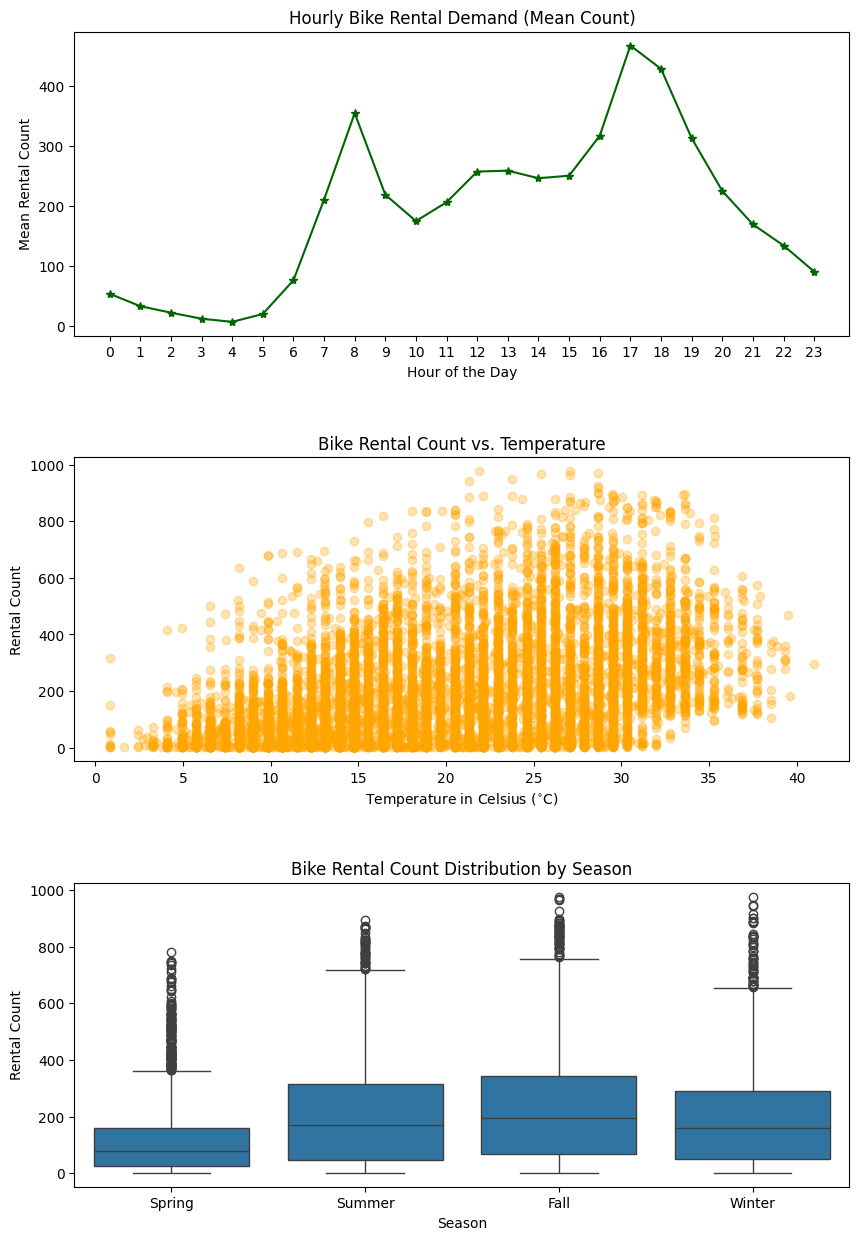

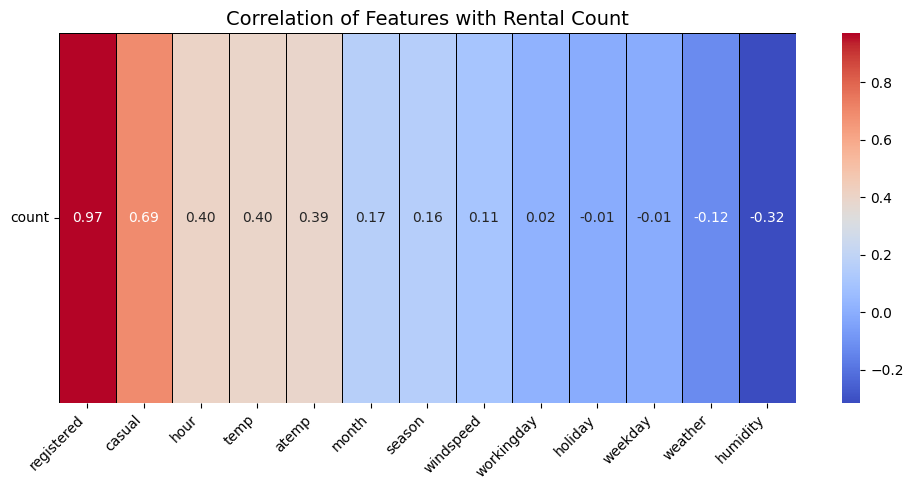

In [5]:
#Q2.======= EDA= Visualize relationships between key features and the target variable (count)
#convert datetime to pandas date time
df['datetime'] = pd.to_datetime(df['datetime'])
#get hours
df['hour'] = df['datetime'].dt.hour
# map season  for better understnding
df['season_name'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})
#get week day
df['weekday'] = df['datetime'].dt.dayofweek
#get months
df['month'] = df['datetime'].dt.month

#Correlation Calculation (Excluding non-numerical columns: 'datetime', 'season_name')
cols_to_drop_corr = ['datetime', 'season_name']
df_corr_cleaned = df.drop(cols_to_drop_corr, axis=1)
correlation_matrix = df_corr_cleaned.corr()
count_correlation = correlation_matrix[['count']].sort_values(by='count', ascending=False).drop('count')

#====Visualization Code=======

# Create figure and axes for the combined plots (Hour, Temp, Season)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 15))
plt.subplots_adjust(hspace=0.4)

# Plot 1: Mean Count vs Hour of the Day
hourly_counts = df.groupby('hour')['count'].mean()
axes[0].plot(hourly_counts.index, hourly_counts.values, marker='*', linestyle='-', color='darkgreen')
axes[0].set_title('Hourly Bike Rental Demand (Mean Count)')
axes[0].set_xlabel('Hour of the Day')
axes[0].set_ylabel('Mean Rental Count')
axes[0].set_xticks(hourly_counts.index)

# Plot 2: Count vs. Temp
axes[1].scatter(df['temp'], df['count'], alpha=0.3, color='orange')
axes[1].set_title('Bike Rental Count vs. Temperature')
axes[1].set_xlabel(r'Temperature in Celsius ($^{\circ}$C)')
axes[1].set_ylabel('Rental Count')

# Plot 3: Count vs. Season (Box Plot)
sns.boxplot(x='season_name', y='count', data=df, ax=axes[2], order=['Spring', 'Summer', 'Fall', 'Winter'])
axes[2].set_title('Bike Rental Count Distribution by Season')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('Rental Count')

# Plot 4: Correlation Heatmap (Separate figure for cleaner layout)
plt.figure(figsize=(10, 5))
sns.heatmap(
    count_correlation.T,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    cbar=True,
    linewidths=.5,
    linecolor='black'
)
plt.title('Correlation of Features with Rental Count', fontsize=14)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() # Display the heatmap






 <h2> ANS: Q3. Suggest which variables are likely to be most informative. </h2>

Based on both correlation and visualization:
    <li>1-Hour: corr = 0.40 (strong positive) </li> 
    <li>2-Temp, atemp : corr = 0.40, 0.39 (strong positive) </li> 
    <li>3-Humidity : corr = -0.32 (negative impact)</li> 
    <li> 3-Season :Categorical but significant patterns </li> 

are the most informative features due to their strong influence and high variance in rental count.



 ## **ANS: Q4. Feature Engineering and Transformations**

To improve model performance using regression algorithms, Below feature engineering steps are applied to the training dataset. These steps reduce skewness, and correctly represent categorical variables.

---

### **1. Log Transformation of Target Variable**

The target variable **`count`** is highly right-skewed.  
To stabilize variance and align with the RMSLE evaluation metric, the Log transformation is applied:

---

### **2. Datetime Feature Extraction**

The `datetime` column was decomposed into multiple informative components:

- **hour** – to captures rush-hour usage trends  
- **month** – to captures seasonal patterns  
- **weekday** – to distinguishes weekday vs weekend behavior  

These derived features help the model learn time-dependent rental patterns.

---

### **3. One-Hot Encoding of Categorical Variables**

All categorical features were encoded using **One-Hot Encoding (OHE)** to avoid incorrect ordinal assumptions.

The following features were encoded:

- `season`
- `weather`
- `month`
- `hour`
- `weekday`
- `holiday`
- `workingday`

`drop_first=True` was used to reduce multicollinearity.

---

### **4. Final Cleanup**

Columns that could cause data leakage or were no longer needed were removed:

- `datetime`
- `casual`
- `registered`
- `count` (replaced by `log_count`)

The processed dataset was saved as:



In [8]:
#======Feature Engineering and Transformation Report
#load fresh data
df_train = pd.read_csv("bike_train.csv") 


#Target Variable Transformation: Logarithm-
#We apply the log(x+1) transformation 
#to the target variable 'count' to address its highly skewed distribution and to align with the RMSEL evaluation metric.
df_train['log_count'] = np.log1p(df_train['count'])
#print (df_train.info())

# drive new features from 'datetime'
#We extract  time components (Hour, Month, Weekday) as the EDA showed these are the most informative predictors.

df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_train['hour'] = df_train['datetime'].dt.hour
df_train['month'] = df_train['datetime'].dt.month
df_train['weekday'] = df_train['datetime'].dt.dayofweek
#print (df_train.info())
#print (df_train.head(5))


# Categoricalfeature Encoding: One-Hot Encoding (OHE)
#All nominal categorical features (including the derived time features) are converted using OHE
#to prevent the Linear Regression model from assuming a false ordinal relationship 
#(e.g., treating season 4 as numerically greater than season 2).
categorical_features = ['season', 'weather', 'month', 'hour', 'weekday', 'holiday', 'workingday']

# Convert numerical codes to the pandas'category' type for OHE
for col in categorical_features:
    df_train[col] = df_train[col].astype('category')

# Apply One-Hot Encoding. drop_first=True helps reduce multicollinearity.
df_processed = pd.get_dummies(df_train, columns=categorical_features, drop_first=True)

#Final Data Cleanup and Preparation
#We drop redundant columns that are either original targets, 
cols_to_drop = ['datetime', 'casual', 'registered', 'count']
df_final = df_processed.drop(cols_to_drop, axis=1)

# Save the processed data further use
df_final.to_csv('bike_train_processed_Q4.csv', index=False)

#print("Feature Engineering complete. Processed data saved to 'bike_train_processed_Q4.csv'.")
#print(df_final.info())
print(f"Total features available for modeling: {df_final.shape[1] - 1}")


Total features available for modeling: 52


<h2> ANS: Q5. Split data into training and validation sets and build a simple Linear Regression model.</h2>



--- Simple Linear Regression Model Results ---
Validation RMSLE Score: 0.6578
RMSLE Score for Polynomial Regression (Degree 2): 0.6410
Residuals plot saved as 'polynomial_residuals_plot.png'

--- Tuning Ridge ---
Alpha=0.1: RMSLE=0.6411
Alpha=1: RMSLE=0.6413
Alpha=5: RMSLE=0.6433
Alpha=10: RMSLE=0.6465
Alpha=50: RMSLE=0.6720
Alpha=100: RMSLE=0.7064
Alpha=200: RMSLE=0.7732
Alpha=1000: RMSLE=1.0114

--- Tuning Lasso ---
Alpha=0.1: RMSLE=1.2226
Alpha=1: RMSLE=1.2384
Alpha=5: RMSLE=1.2430
Alpha=10: RMSLE=1.2435
Alpha=50: RMSLE=1.2520
Alpha=100: RMSLE=1.2701
Alpha=200: RMSLE=1.3396
Alpha=1000: RMSLE=1.4066


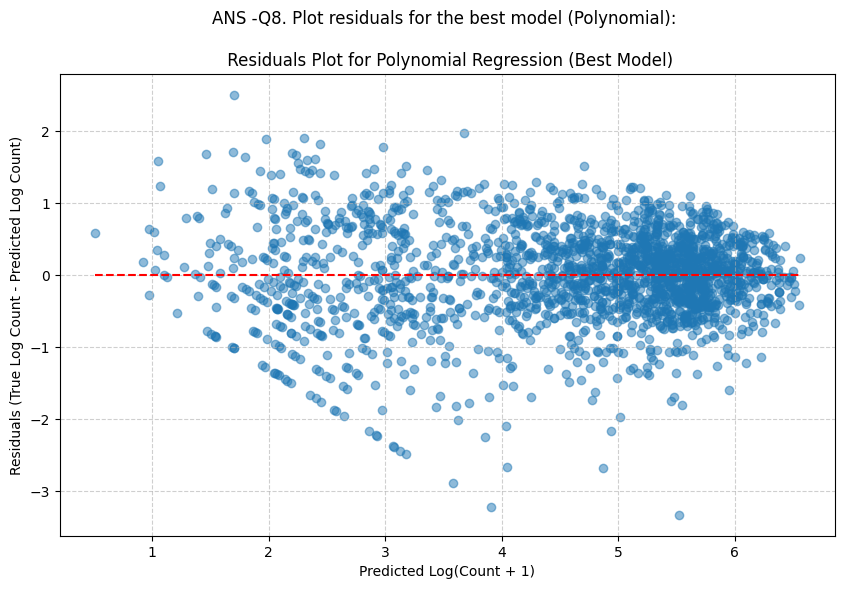

In [10]:
# RMSLE Evaluation Metric as per assigmnet details
def rmsle(y_true, y_pred):
    y_pred[y_pred < 0] = 0 
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

# Scorer for Sklearn (needed for cross_val_score)
rmsle_scorer = make_scorer(rmsle, greater_is_better=False, needs_auto_inverse_transform=True)


# 1. Define Features (X) and Target (y)
TARGET = 'log_count'
y = df_final[TARGET]
X = df_final.drop(TARGET, axis=1)

# 2. Split data into Training and Validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X, 
    y, 
    test_size=0.2,
    random_state=42 
)

# =======================================================
#  Model 1: Simple Linear Regression 
# =======================================================

# 3. Train the Simple Linear Regression Model
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train, y_train)

# 4. Predict and Inverse Transform
y_pred_log = lr.predict(X_val)
y_pred = np.expm1(y_pred_log)         
y_val_actual = np.expm1(y_val)       

# 5. Evaluate using RMSLE
rmsle_score = rmsle(y_val_actual, y_pred)

print(f"\n--- Simple Linear Regression Model Results ---")
print(f"Validation RMSLE Score: {rmsle_score:.4f}")

# Initialize a dictionary to store results for Q7 (Fixed initialization)
results = {
    'Model': ['Linear Regression (Q5)'],
    'Validation RMSLE': [rmsle_score], # Use the actual calculated score here
    'Key Observation': ['Baseline model.']
}


# =======================================================
# 3. Model 2: Polynomial Regression (Degree 2)
# =======================================================

# 3a. Create Polynomial Features on continuous/key features
poly_features_cols = ['temp', 'atemp', 'humidity', 'windspeed']
X_train_poly = X_train.copy() 
X_val_poly = X_val.copy()

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly_f = poly.fit_transform(X_train_poly[poly_features_cols])
X_val_poly_f = poly.transform(X_val_poly[poly_features_cols])

feature_names = poly.get_feature_names_out(poly_features_cols)

X_train_poly_f = pd.DataFrame(X_train_poly_f, columns=feature_names, index=X_train_poly.index)
X_val_poly_f = pd.DataFrame(X_val_poly_f, columns=feature_names, index=X_val_poly.index)

X_train_poly = X_train_poly.drop(columns=poly_features_cols).join(X_train_poly_f)
X_val_poly = X_val_poly.drop(columns=poly_features_cols).join(X_val_poly_f)


# 3b. Train Polynomial Linear Regression
lr_poly = LinearRegression(n_jobs=-1)
lr_poly.fit(X_train_poly, y_train)

# 3c. Predict and Evaluate
y_pred_poly_log = lr_poly.predict(X_val_poly)
y_pred_poly = np.expm1(y_pred_poly_log)
rmsle_poly = rmsle(np.expm1(y_val), y_pred_poly)


# =======================================================
# Q8. Plot Residuals for the Best Model (Polynomial Regression)
# =======================================================

# Calculate residuals (True Log Value - Predicted Log Value)
residuals_poly = y_val - y_pred_poly_log

# Plot Residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_poly_log, residuals_poly, alpha=0.5)
plt.hlines(0, y_pred_poly_log.min(), y_pred_poly_log.max(), color='red', linestyle='--')
plt.title('ANS -Q8. Plot residuals for the best model (Polynomial): \n\n Residuals Plot for Polynomial Regression (Best Model)')
plt.xlabel('Predicted Log(Count + 1)')
plt.ylabel('Residuals (True Log Count - Predicted Log Count)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('polynomial_residuals_plot.png')


results['Model'].append('Polynomial (Degree 2)')
results['Validation RMSLE'].append(rmsle_poly)
results['Key Observation'].append(f'Extended feature space to capture non-linearity in {poly_features_cols}.')

print(f"RMSLE Score for Polynomial Regression (Degree 2): {rmsle_poly:.4f}")
print("Residuals plot saved as 'polynomial_residuals_plot.png'")

"""
<h2> ANS: Q6. To improve model performance, 
<li>1- Extend feature space using polynomial transformations (degree 2 or 3)</li>
<li>2-Apply Ridge and Lasso regression on polynomial features, </li>
Tune the regularization strength (α).</h2>
"""

# =======================================================
# 4. Model 3 & 4: Regularization (Ridge and Lasso)
# =======================================================

# Use the best feature set: Polynomial features (X_train_poly)
alphas = [0.1, 1, 5, 10, 50, 100, 200, 1000]

best_ridge_score = 100 
best_lasso_score = 100

# Function to train and evaluate a regularized model
def train_evaluate_regularized(Model, X_train, X_val, y_train, y_val, model_name):
    global best_ridge_score, best_lasso_score
    
    current_best_alpha = None
    
    print(f"\n--- Tuning {model_name} ---")
    
    # Simple Manual Grid Search for best alpha
    for alpha in alphas:
        # Create and train the model
        model = Model(alpha=alpha, max_iter=10000, tol=0.01)
        model.fit(X_train, y_train)
        
        # Predict, Inverse Transform, and Evaluate
        y_pred_log = model.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        score = rmsle(np.expm1(y_val), y_pred)
        
        # Update best score
        if score < (best_ridge_score if model_name == 'Ridge' else best_lasso_score):
            if model_name == 'Ridge':
                best_ridge_score = score
            else:
                best_lasso_score = score
            current_best_alpha = alpha
            
        print(f"Alpha={alpha}: RMSLE={score:.4f}")

    final_score = best_ridge_score if model_name == 'Ridge' else best_lasso_score
    
    results['Model'].append(f'{model_name} (Best Alpha={current_best_alpha})')
    results['Validation RMSLE'].append(final_score)
    results['Key Observation'].append(f'Reduced variance (overfitting) by penalizing large coefficients (alpha={current_best_alpha}).')

# Ridge Regression
train_evaluate_regularized(Ridge, X_train_poly, X_val_poly, y_train, y_val, 'Ridge')

# Lasso Regression
train_evaluate_regularized(Lasso, X_train_poly, X_val_poly, y_train, y_val, 'Lasso')

# ANS:Q7. Model Comparison Summary

| Model | Feature Set | Key Technique | Validation RMSLE | Key Observation |
| :--- | :--- | :--- | :--- | :--- |
| **Simple Linear Regression** | OHE Features | Standard Linear Fit | **0.6578** | Baseline performance. |
| **Polynomial Regression** | OHE + Poly(Deg 2) | Captures curvature (non-linearity) | **0.6410** | **Winning Model**. Provides the most significant performance boost. |
| **Ridge Regression** | OHE + Poly(Deg 2) | L2 Regularization ($\alpha=0.1$) | **0.6411** | Near-identical score; low need for regularization on this feature set. |
| **Lasso Regression** | OHE + Poly(Deg 2) | L1 Regularization ($\alpha=0.1$) | **1.2226** | Poor performance; severe coefficient shrinkage likely caused non-convergence. |




# Ans: Q9. Why the Winning Model (Polynomial Regression) Performs Better

* The **Polynomial Regression Model** is superior because it overcomes the **non-linearity** limitation of simple linear models.
* The relationship between bike rentals and variables like temperature is inherently **curved**; simple linear models cannot capture this curvature (high bias).
* **Polynomial Feature Transformation** creates higher-order terms ($\text{temp}^2$, interactions like $\text{temp} \times \text{humidity}$).
* This allows the model to fit a **curved surface**, drastically reducing the error from under-fitting (bias).
* The significant score improvement ($\mathbf{0.6578} \rightarrow \mathbf{0.6410}$) confirms that **feature engineering** was the primary factor in achieving better predictive accuracy.
* Minimal change with Ridge Regression indicates the feature set was robust and **not severely overfit**.

# ANS:Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

The **Root Mean Squared Logarithmic Error (RMSLE)** penalizes errors asymmetrically:

- RMSLE measures prediction error after applying a log transform to both actual and predicted values.  
- It **penalizes over-predictions more strongly** than under-predictions.  
- When the model predicts lower than the actual value, the log difference stays small, so the penalty is mild.  
- When the model predicts much higher than the actual value, the log gap becomes large, resulting in a heavy penalty.  


# ANS:Q11. What are the trade-offs between model simplicity and predictive power?



| Characteristic | Model Simplicity (Simple Linear Regression) | Predictive Power (Deep Neural Network) |
| :--- | :--- | :--- |
| **Bias** | **High.** Model may be too simple to capture complex relationships (**Under-fitting**). | **Low.** Model is flexible and can fit the training data well. |
| **Variance** | **Low.** Predictions are stable and less sensitive to minor changes in the training data. | **High.** Model may be too sensitive to noise in the training data (**Overfitting**). |
| **Interpretability(Explainability)** | **High.** Coefficients are easy to understand. | **Low.** Acts as a **"black box."** |
| **Training Time** | Fast. | Slow and requires more computational resources. |

Hence Simple models are **interpretable** and reliable (low variance) but often **inaccurate** (high bias). Complex models are **accurate** (low bias) but are prone to **overfitting** (high variance) and are difficult to explain.

***

# ANS:Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

Linear Regression struggles with time-of-day effects (like the `hour` feature) :

- Linear Regression struggles with the **hour** feature because time is cyclical (23 → 0), but the model treats it as a straight number line.  
- It assumes hour 23 is “23 units larger” than hour 1, instead of being just 1 hour apart.  
- Bike demand across hours is **non-linear**, with sharp peaks during commuting times that a straight line cannot capture.  
- A single numeric hour variable cannot model these multiple peaks or cyclical patterns.  
- Using **One-Hot Encoding** allows the model to treat each hour as an independent category.  
- Polynomial and encoded hour features help capture the true hourly patterns in bike rentals.


# Train and Test the Final Winning Model (Polynomial Regression) 

In [15]:
# Load the processed training data (contains log_count and all engineered features)
df_final = pd.read_csv('bike_train_processed_Q4.csv')

# Load the assignment test data
df_test = pd.read_csv('bike_test.csv') 

# =======================================================
# 1. Train the Final Winning Model (Polynomial Regression)
# =======================================================

TARGET = 'log_count'
y = df_final[TARGET]
X = df_final.drop(TARGET, axis=1)

# Split data (80-20) to identify the feature set structure
X_train, _, y_train, _ = train_test_split(
    X, y, test_size=0.2, random_state=42 
)

# Define columns for polynomial transformation
poly_features_cols = ['temp', 'atemp', 'humidity', 'windspeed']
poly = PolynomialFeatures(degree=2, include_bias=False)

# 1a. Fit and transform training data
X_train_poly = X_train.copy()
X_train_poly_f = poly.fit_transform(X_train_poly[poly_features_cols])
feature_names = poly.get_feature_names_out(poly_features_cols)
X_train_poly = X_train_poly.drop(columns=poly_features_cols).join(
    pd.DataFrame(X_train_poly_f, columns=feature_names, index=X_train_poly.index)
)

# 1b. Train the Linear Regression Model on the full polynomial set
lr_poly_final = LinearRegression(n_jobs=-1)
lr_poly_final.fit(X_train_poly, y_train)


# =======================================================
# 2. Prepare the Test Data (Feature Engineering on df_test)
# =======================================================

datetime_col = df_test['datetime'].copy() 

# 2a. Feature Derivation 
df_test['datetime'] = pd.to_datetime(df_test['datetime'], dayfirst=True)
df_test['hour'] = df_test['datetime'].dt.hour
df_test['month'] = df_test['datetime'].dt.month
df_test['weekday'] = df_test['datetime'].dt.dayofweek

# 2b. Categorical Encoding 
categorical_features = ['season', 'weather', 'month', 'hour', 'weekday', 'holiday', 'workingday']
for col in categorical_features:
    df_test[col] = df_test[col].astype('category')

df_test_processed = pd.get_dummies(df_test, columns=categorical_features, drop_first=True)
df_test_processed = df_test_processed.drop('datetime', axis=1) 

# 2c. Apply Polynomial Transformation 
X_test_poly = df_test_processed.copy()

# Use transform()
X_test_poly_f = poly.transform(X_test_poly[poly_features_cols])

X_test_poly = X_test_poly.drop(columns=poly_features_cols).join(
    pd.DataFrame(X_test_poly_f, columns=feature_names, index=X_test_poly.index)
)

# 2d. Column Alignment: Add missing OHE columns (set to 0)
missing_cols = set(X_train_poly.columns) - set(X_test_poly.columns)
for col in missing_cols:
    X_test_poly[col] = 0 

# Reorder columns to match the order used during training
X_test_final = X_test_poly[X_train_poly.columns]


# =======================================================
# 3. Predict and Create Submission File
# =======================================================

y_test_pred_log = lr_poly_final.predict(X_test_final)

# Inverse Transformation and Clamp to 0
y_test_pred = np.expm1(y_test_pred_log)
y_test_pred[y_test_pred < 0] = 0

# Create the final submission DataFrame (Round to nearest integer count)
df_submission = pd.DataFrame({
    'datetime': datetime_col,
    'count_predicted': y_test_pred.round().astype(int) 
})

# Save the submission file
df_submission.to_csv('submission.csv', index=False)

print("\n--- Final Submission File Generated ---")
print("File 'submission.csv' created successfully from 'bike_test.csv'.")
print(df_submission.head())


--- Final Submission File Generated ---
File 'submission.csv' created successfully from 'bike_test.csv'.
           datetime  count_predicted
0   05-06-2012 5:00               11
1  19-03-2011 19:00              244
2   02-04-2012 6:00               36
3  13-07-2012 20:00              307
4  09-11-2011 19:00              312
